In [8]:
import tensorflow as tf
import csv
import sys
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import keras
from keras import layers
from tensorflow.keras.preprocessing import image
from keras.layers import Conv2D, MaxPooling2D, Flatten , Dropout
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt



In [4]:

# Import the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Reading the data labels:             

0: T-shirt/top;

1: Trouser;

2: Pullover;

3: Dress;

4: Coat;

5: Sandal;

6: Shirt;

7: Sneaker;

8: Bag;

9: Ankle boot

In [12]:
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0
train_images.shape


(60000, 28, 28)

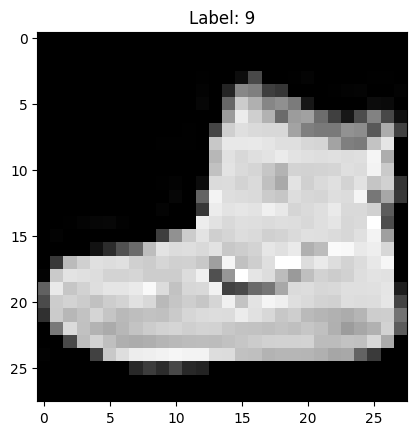

In [9]:
image_index = 0
example_image = train_images[image_index]

# Display the image using Matplotlib
plt.imshow(example_image, cmap='gray')  # Use 'gray' colormap for grayscale images
plt.title(f"Label: {train_labels[image_index]}")  # Display the image label
plt.show()

In [25]:

train_images_reshaped=train_images.reshape(train_images.shape[0],-1)
model = Sequential([
Dense(512, input_dim=784, activation='relu'),
Dropout(0.2),
Dense(256, activation='relu'),
Dropout(0.4),
Dense(128, activation='relu'),
Dense(10, activation='softmax')  # Output layer for 10 classes
])

# Compile the model with a reasonable learning rate and track accuracy
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(
    train_images_reshaped, train_labels,
    epochs=35,
    callbacks=[early_stopping]
)


Epoch 1/35
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 18ms/step - accuracy: 0.4564 - loss: 1.6080
Epoch 2/35
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.7013 - loss: 0.7947
Epoch 3/35
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.7513 - loss: 0.6781
Epoch 4/35
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.7757 - loss: 0.6120
Epoch 5/35
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.7890 - loss: 0.5765
Epoch 6/35
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - accuracy: 0.8028 - loss: 0.5393
Epoch 7/35
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8094 - loss: 0.5224
Epoch 8/35
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8192 - loss: 0.5014
Epoch 9/35
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 11ms/step - accuracy: 0.8281 - loss: 0.4814
Epoch 10/35
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8319 - loss: 0.4638
Epoch 11/35
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8352 - loss: 0.4556
Epoch 12

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


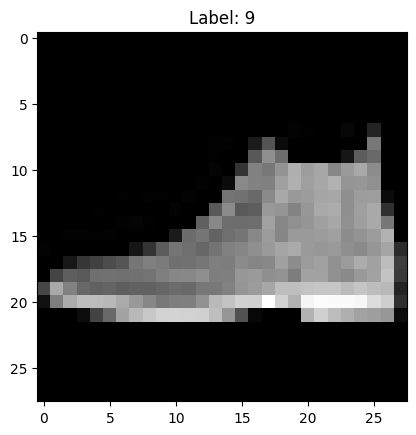

Predicted class for the image: 9


In [23]:
image_index = 0
example_image=model.predict(test_images[0].reshape(1,-1)) # Reshape to (1, 784) for a single image
# Display the image using Matplotlib
plt.imshow(test_images[image_index], cmap='gray')  # Display the original image
plt.title(f"Label: {test_labels[image_index]}")  # Display the image label
plt.show()
predicted_class = np.argmax(example_image)
print(f'Predicted class for the image: {predicted_class}')

In [27]:


# Reshape the entire test set for prediction
test_images_reshaped = test_images.reshape(test_images.shape[0], -1)

# Get predictions for the entire test set
predictions = model.predict(test_images_reshaped)
predicted_classes = np.argmax(predictions, axis=1)

# Calculate accuracy
accuracy = accuracy_score(test_labels, predicted_classes)
print(f"Accuracy on test data: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy on test data: 0.8754
